In [ ]:
#Load dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("turkibintalib/saudi-arabia-used-cars-dataset") #this dataset is ideal for building models to predict car prices based on various features.

import pandas as pd

#load dataset into a dataframe
df = pd.read_csv(path+'/UsedCarsSA_Clean_EN.csv')

#Looking for missing values
df.isnull().sum() # There are no missing values

,0
Make,0
Type,0
Year,0
Origin,0
Color,0
Options,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


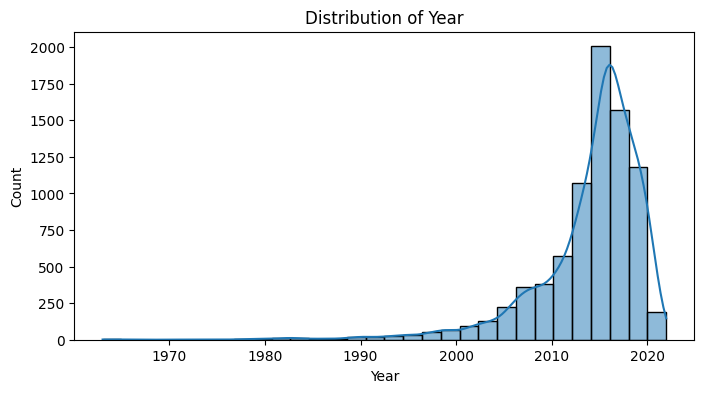

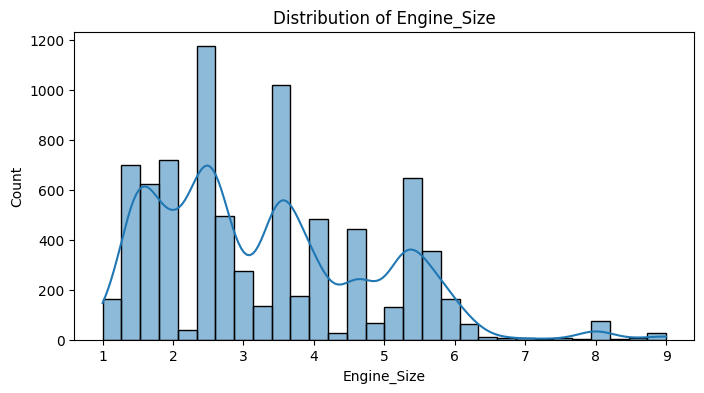

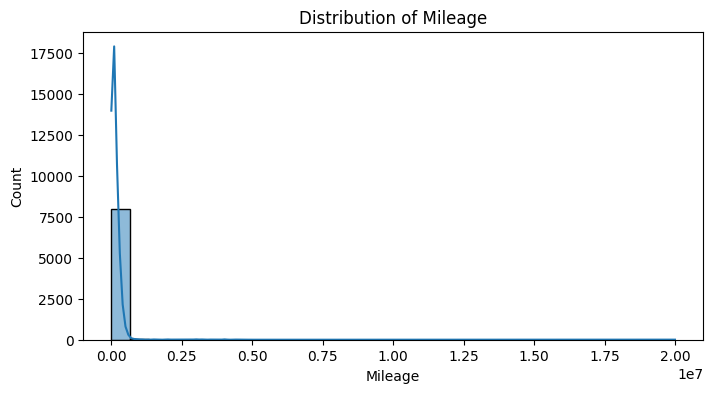

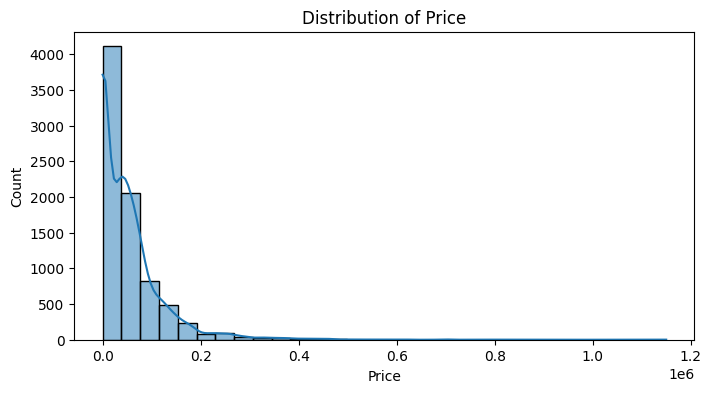

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


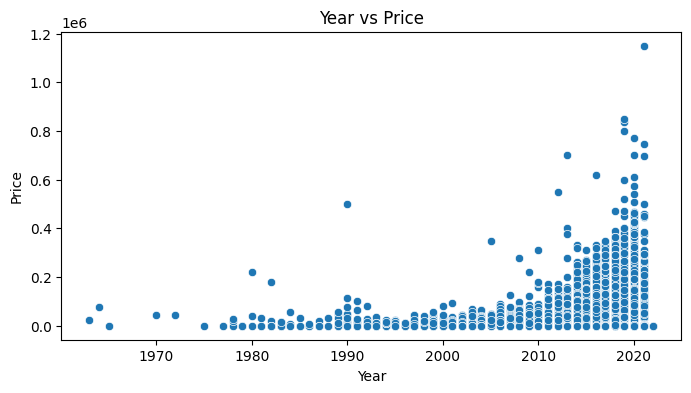

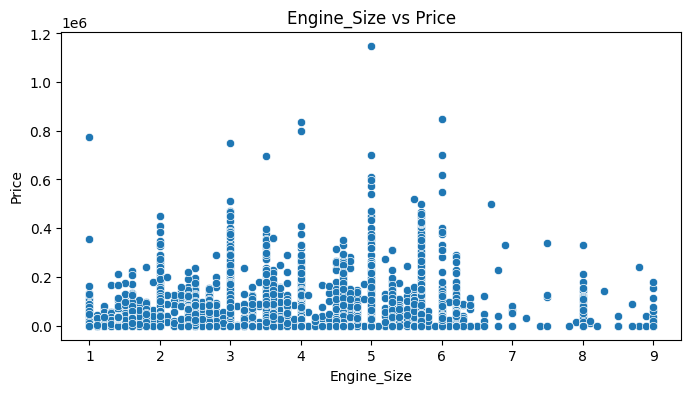

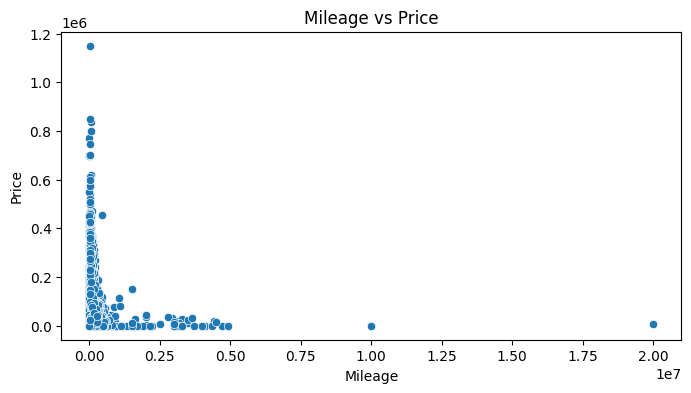

In [ ]:
for col in numeric_cols:
    if col != 'Price':
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[col], y=df['Price'])
        plt.title(f'{col} vs Price')
        plt.xlabel(col)
        plt.ylabel("Price")
        plt.show()




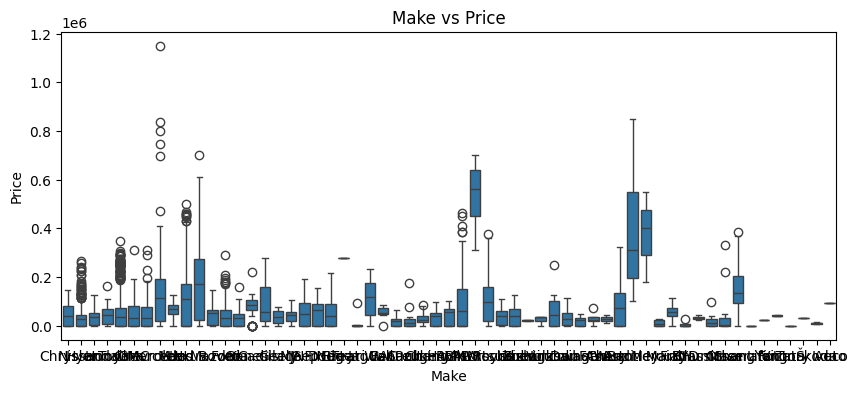

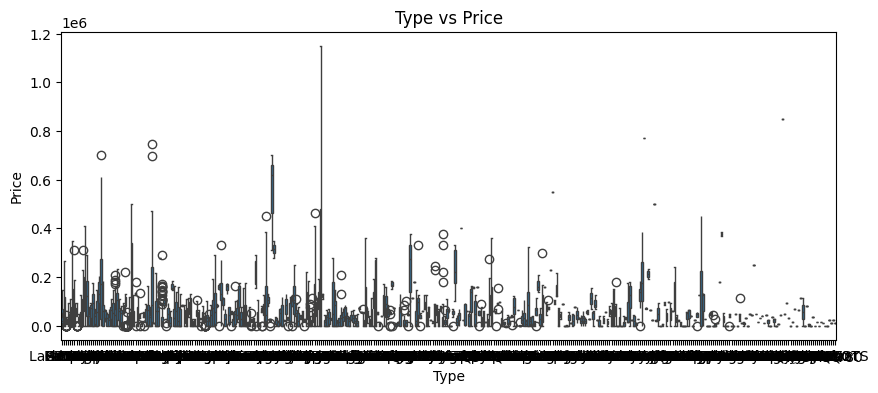

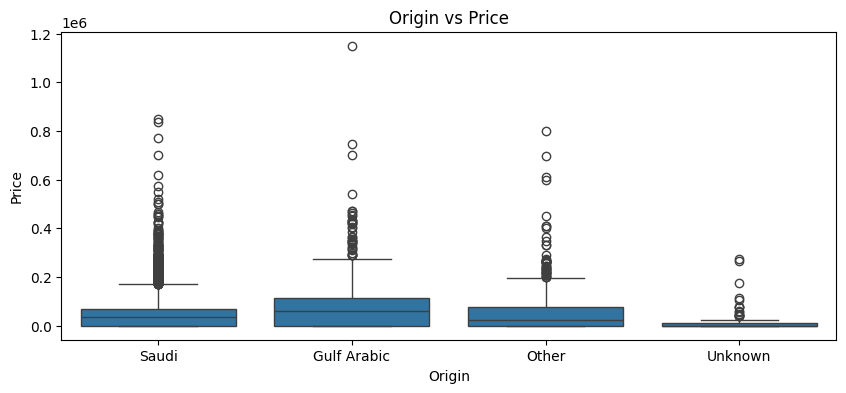

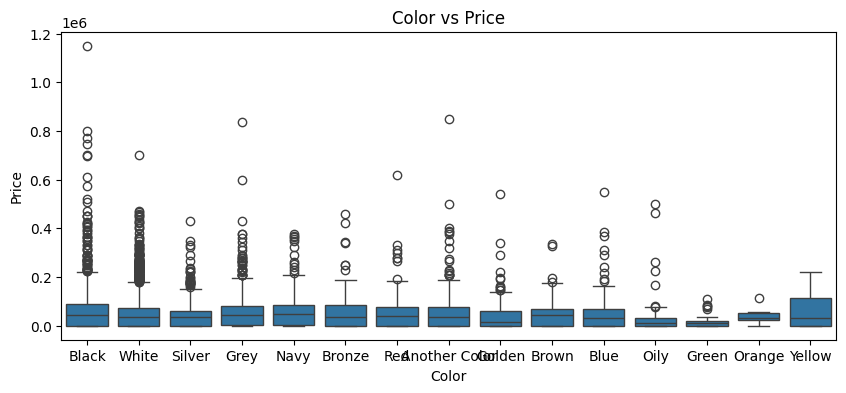

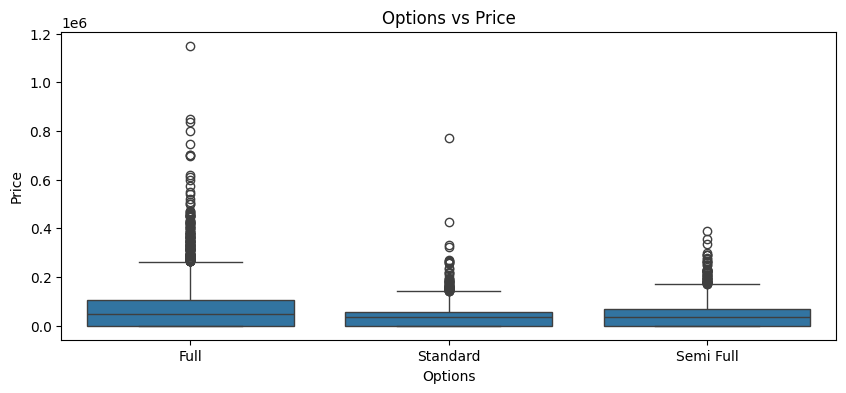

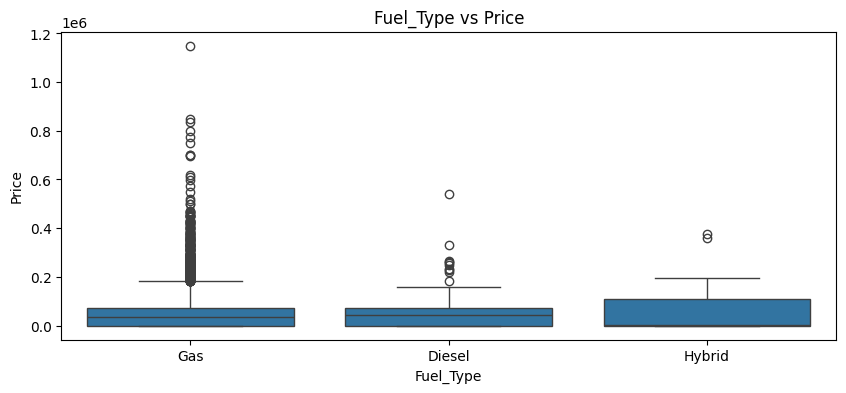

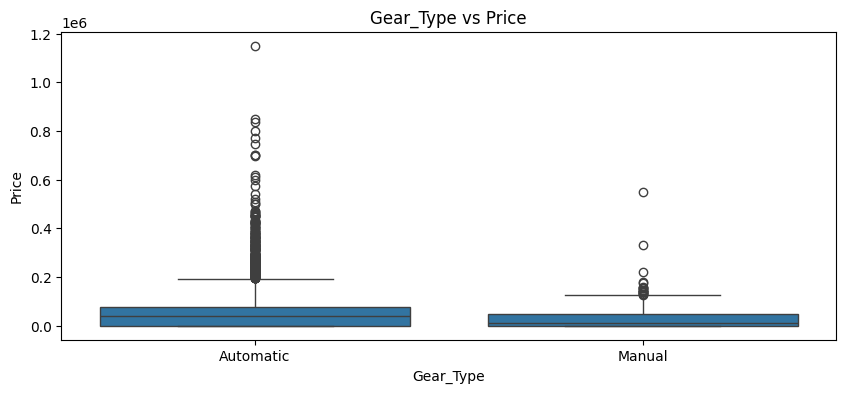

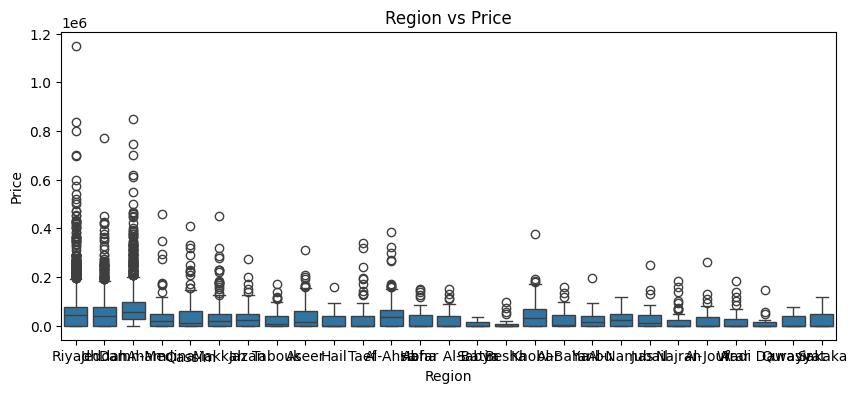

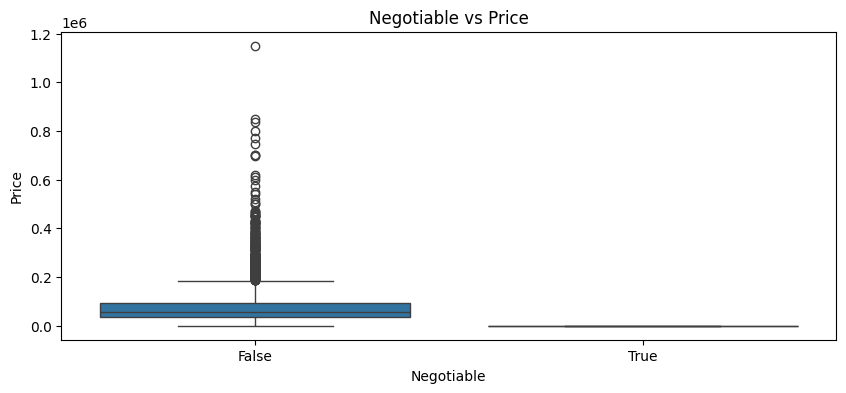

In [ ]:
#ENCODED
categorical_cols = [col for col in df.columns if col not in numeric_cols and col != 'Price']

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], y=df['Price'])
    plt.title(f'{col} vs Price')
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


ValueError: could not convert string to float: 'Chrysler'

<Figure size 1200x800 with 0 Axes>

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X = df.drop('Price', axis=1)
X_scaled = StandardScaler().fit_transform(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X.shape[1])]
print(vif_df)


ValueError: could not convert string to float: 'Chrysler'